# MA/V OU Validation

Use an Ornstein-Uhlenbeck model on the dynamic MA/V spread. Thresholds for regime filters are calibrated on pre-2020 data; the final validation run is from 2020-01-01 onward.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
TEST_START = "2020-01-01"
TRAIN_EVAL_START = "2008-03-19"

# OU strategy parameters.
HEDGE_LOOKBACK = 252
OU_LOOKBACK = 378
ENTRY_Z = 1.0
EXIT_Z = 0.75
E_STOP = 3.9
MIN_HALF_LIFE = 1
MAX_HALF_LIFE = 60
MIN_HOLD_DAYS = 1
COOLDOWN_DAYS = 1

# Regime filter settings. Thresholds are calibrated on pre-2020 training data only.
REGIME_LOOKBACK = 126
BETA_STABILITY_LOOKBACK = 20
MIN_CORR_QUANTILE = 0.75
MAX_BETA_CHANGE_QUANTILE = 0.90
MAX_OU_SIGMA_QUANTILE = 0.90

USE_CORRELATION_FILTER = True
USE_BETA_STABILITY_FILTER = True
USE_OU_SIGMA_FILTER = True


In [3]:
def load_yfinance_csv(path, asset_name):
    df = pd.read_csv(path)
    df = df.iloc[2:].copy()
    df.rename(columns={"Price": "Date"}, inplace=True)

    df = df[["Date", "Close"]].copy()
    df["Date"] = pd.to_datetime(df["Date"])

    df[asset_name] = pd.to_numeric(df["Close"], errors="coerce")
    df = df[["Date", asset_name]].dropna()

    return df


v = load_yfinance_csv("V_daily.csv", "V")
ma = load_yfinance_csv("MA_daily.csv", "MA")

df = pd.merge(v, ma, on="Date", how="inner")
df = df.sort_values("Date").reset_index(drop=True)

df["V"] = pd.to_numeric(df["V"], errors="coerce")
df["MA"] = pd.to_numeric(df["MA"], errors="coerce")

df = df.dropna(subset=["V", "MA"])
df = df[(df["V"] > 0) & (df["MA"] > 0)].copy()
df = df.sort_values("Date").reset_index(drop=True)

df["V_ret"] = df["V"].pct_change()
df["MA_ret"] = df["MA"].pct_change()
df["log_V"] = np.log(df["V"])
df["log_MA"] = np.log(df["MA"])

df[["Date", "V", "MA", "V_ret", "MA_ret"]].head()


,Date,V,MA,V_ret,MA_ret
0,2008-03-19,14.1250,20.839001,NaN,NaN
1,2008-03-20,16.0875,22.038000,0.138938,0.057536
2,2008-03-24,14.9325,21.650000,-0.071795,-0.017606
3,2008-03-25,15.8125,22.497999,0.058932,0.039169
4,2008-03-26,15.9900,22.285000,0.011225,-0.009467


In [4]:
def estimate_ou_params(spread_series):
    """Estimate discrete OU/AR(1) parameters from a trailing spread window."""
    x = np.asarray(spread_series, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 20 or np.std(x[:-1]) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    x_lag = x[:-1]
    x_next = x[1:]
    phi, intercept = np.polyfit(x_lag, x_next, 1)

    # A stationary OU process maps to 0 < phi < 1 in discrete time.
    if not np.isfinite(phi) or phi <= 0 or phi >= 1:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    theta = -np.log(phi)
    mu = intercept / (1 - phi)
    residuals = x_next - (intercept + phi * x_lag)
    residual_sigma = np.std(residuals, ddof=1)
    stationary_sigma = residual_sigma / np.sqrt(1 - phi**2)
    half_life = np.log(2) / theta if theta > 0 else np.nan

    return mu, phi, theta, stationary_sigma, half_life


def add_ou_features(price_df, hedge_lookback, ou_lookback, regime_lookback, beta_stability_lookback):
    features = price_df.copy().reset_index(drop=True)

    for col in ["beta", "spread", "ou_mu", "ou_phi", "ou_theta", "ou_sigma", "half_life", "ou_z"]:
        features[col] = np.nan

    log_v = features["log_V"].to_numpy()
    log_ma = features["log_MA"].to_numpy()
    start = max(hedge_lookback, ou_lookback + 2)

    for i in range(start, len(features)):
        hedge_start = i - hedge_lookback
        beta = np.polyfit(log_v[hedge_start:i], log_ma[hedge_start:i], 1)[0]
        features.loc[i, "beta"] = beta

        ou_start = i - ou_lookback
        spread_history = log_ma[ou_start:i] - beta * log_v[ou_start:i]
        ou_mu, ou_phi, ou_theta, ou_sigma, half_life = estimate_ou_params(spread_history)
        current_spread = log_ma[i] - beta * log_v[i]

        features.loc[i, "spread"] = current_spread
        features.loc[i, "ou_mu"] = ou_mu
        features.loc[i, "ou_phi"] = ou_phi
        features.loc[i, "ou_theta"] = ou_theta
        features.loc[i, "ou_sigma"] = ou_sigma
        features.loc[i, "half_life"] = half_life

        if np.isfinite(ou_sigma) and ou_sigma > 0:
            features.loc[i, "ou_z"] = (current_spread - ou_mu) / ou_sigma

    features["return_corr"] = features["V_ret"].rolling(regime_lookback).corr(features["MA_ret"])
    features["beta_change"] = features["beta"].diff().abs()
    features["beta_change_avg"] = features["beta_change"].rolling(beta_stability_lookback).mean()

    return features


In [5]:
def calibrate_regime_thresholds(feature_df):
    training_features = feature_df[(feature_df["Date"] >= "2000-01-01") & (feature_df["Date"] < TEST_START)].copy()

    return {
        "min_corr": training_features["return_corr"].quantile(MIN_CORR_QUANTILE),
        "max_beta_change": training_features["beta_change_avg"].quantile(MAX_BETA_CHANGE_QUANTILE),
        "max_ou_sigma": training_features["ou_sigma"].quantile(MAX_OU_SIGMA_QUANTILE),
    }


def run_ou_strategy(
    feature_df,
    label,
    evaluate_from,
    evaluate_to,
    regime_thresholds,
    hedge_lookback,
    ou_lookback,
    entry_z,
    exit_z,
    e_stop,
    min_half_life,
    max_half_life,
    min_hold_days,
    cooldown_days,
):
    result = feature_df.copy().reset_index(drop=True)

    result["corr_ok"] = True
    result["beta_stable"] = True
    result["ou_sigma_ok"] = True

    if USE_CORRELATION_FILTER:
        result["corr_ok"] = result["return_corr"] >= regime_thresholds["min_corr"]
    if USE_BETA_STABILITY_FILTER:
        result["beta_stable"] = result["beta_change_avg"] <= regime_thresholds["max_beta_change"]
    if USE_OU_SIGMA_FILTER:
        result["ou_sigma_ok"] = result["ou_sigma"] <= regime_thresholds["max_ou_sigma"]

    result["half_life_ok"] = result["half_life"].between(min_half_life, max_half_life)
    result["regime_ok"] = result[["corr_ok", "beta_stable", "ou_sigma_ok", "half_life_ok"]].all(axis=1)
    result["position"] = 0.0

    start_idx = int(result.index[result["Date"] >= evaluate_from][0])
    if evaluate_to is None:
        end_idx = len(result)
    else:
        end_candidates = result.index[result["Date"] >= evaluate_to]
        end_idx = int(end_candidates[0]) if len(end_candidates) else len(result)

    current_pos = 0
    entry_idx = None
    cooldown_remaining = 0

    for i in range(start_idx, end_idx):
        z = result.loc[i, "ou_z"]
        regime_ok = bool(result.loc[i, "regime_ok"])

        if pd.isna(z):
            result.loc[i, "position"] = current_pos
            continue

        if current_pos == 0:
            if cooldown_remaining > 0:
                cooldown_remaining -= 1
            elif regime_ok:
                if z > entry_z:
                    current_pos = -1  # short spread: short MA, long V
                    entry_idx = i
                elif z < -entry_z:
                    current_pos = 1  # long spread: long MA, short V
                    entry_idx = i

        elif current_pos == 1:
            holding_days = i - entry_idx if entry_idx is not None else 0
            if z < -e_stop or not regime_ok or (holding_days >= min_hold_days and z > -exit_z):
                current_pos = 0
                entry_idx = None
                cooldown_remaining = cooldown_days

        elif current_pos == -1:
            holding_days = i - entry_idx if entry_idx is not None else 0
            if z > e_stop or not regime_ok or (holding_days >= min_hold_days and z < exit_z):
                current_pos = 0
                entry_idx = None
                cooldown_remaining = cooldown_days

        result.loc[i, "position"] = current_pos

    result["beta_ffill"] = result["beta"].ffill()
    result["spread_ret"] = result["MA_ret"] - result["beta_ffill"] * result["V_ret"]
    result["position_lag"] = result["position"].shift(1).fillna(0)
    result["strategy_ret"] = (result["position_lag"] * result["spread_ret"]).fillna(0)

    result = result.iloc[start_idx:end_idx].copy().reset_index(drop=True)
    result["equity_curve"] = (1 + result["strategy_ret"]).cumprod()
    result["drawdown"] = result["equity_curve"] / result["equity_curve"].cummax() - 1

    mean_ret = result["strategy_ret"].mean()
    std_ret = result["strategy_ret"].std()
    sharpe = np.nan if std_ret == 0 else np.sqrt(252) * mean_ret / std_ret

    return {
        "label": label,
        "hedge_lookback": hedge_lookback,
        "ou_lookback": ou_lookback,
        "entry_z": entry_z,
        "exit_z": exit_z,
        "e_stop": e_stop,
        "max_half_life": max_half_life,
        "start_date": result["Date"].min(),
        "end_date": result["Date"].max(),
        "sharpe": sharpe,
        "total_return": result["equity_curve"].iloc[-1] - 1,
        "max_drawdown": result["drawdown"].min(),
        "num_trades": int((result["position"].diff().abs() > 0).sum()),
        "exposure": result["position"].ne(0).mean(),
        "regime_ok_rate": result["regime_ok"].mean(),
        "final_equity": result["equity_curve"].iloc[-1],
        "backtest_df": result,
    }


In [6]:
feature_df = add_ou_features(
    df,
    hedge_lookback=HEDGE_LOOKBACK,
    ou_lookback=OU_LOOKBACK,
    regime_lookback=REGIME_LOOKBACK,
    beta_stability_lookback=BETA_STABILITY_LOOKBACK,
)
regime_thresholds = calibrate_regime_thresholds(feature_df)

training_result = run_ou_strategy(
    feature_df,
    label="OU training",
    evaluate_from=TRAIN_EVAL_START,
    evaluate_to=TEST_START,
    regime_thresholds=regime_thresholds,
    hedge_lookback=HEDGE_LOOKBACK,
    ou_lookback=OU_LOOKBACK,
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
    e_stop=E_STOP,
    min_half_life=MIN_HALF_LIFE,
    max_half_life=MAX_HALF_LIFE,
    min_hold_days=MIN_HOLD_DAYS,
    cooldown_days=COOLDOWN_DAYS,
)

validation_result = run_ou_strategy(
    feature_df,
    label="OU validation",
    evaluate_from=TEST_START,
    evaluate_to=None,
    regime_thresholds=regime_thresholds,
    hedge_lookback=HEDGE_LOOKBACK,
    ou_lookback=OU_LOOKBACK,
    entry_z=ENTRY_Z,
    exit_z=EXIT_Z,
    e_stop=E_STOP,
    min_half_life=MIN_HALF_LIFE,
    max_half_life=MAX_HALF_LIFE,
    min_hold_days=MIN_HOLD_DAYS,
    cooldown_days=COOLDOWN_DAYS,
)

training_df = training_result["backtest_df"]
validation_df = validation_result["backtest_df"]
thresholds_df = pd.DataFrame([regime_thresholds])
metrics_df = pd.DataFrame([
    {k: v for k, v in training_result.items() if k != "backtest_df"},
    {k: v for k, v in validation_result.items() if k != "backtest_df"},
])

display(thresholds_df)
display(metrics_df)


,min_corr,max_beta_change,max_ou_sigma
0,0.852704,0.00573,0.069085


,label,hedge_lookback,ou_lookback,entry_z,exit_z,e_stop,max_half_life,start_date,end_date,sharpe,total_return,max_drawdown,num_trades,exposure,regime_ok_rate,final_equity
0,OU training,252,378,1.0,0.75,3.9,60,2008-03-19,2019-12-31,1.030953,0.460644,-0.048034,64,0.068059,0.225404,1.460644
1,OU validation,252,378,1.0,0.75,3.9,60,2020-01-02,2026-05-11,1.523508,0.887521,-0.054849,78,0.199123,0.602379,1.887521


In [7]:
trade_log = validation_df[validation_df["position"].diff().fillna(0).abs() > 0].copy()
trade_log = trade_log[[
    "Date", "V", "MA", "beta", "spread", "ou_mu", "ou_sigma", "half_life", "ou_z",
    "return_corr", "beta_change_avg", "regime_ok", "position", "strategy_ret", "equity_curve", "drawdown"
]]

trade_log.head(20)


,Date,V,MA,beta,spread,ou_mu,ou_sigma,half_life,ou_z,return_corr,beta_change_avg,regime_ok,position,strategy_ret,equity_curve,drawdown
2,2020-01-06,189.190002,301.230011,1.199028,-0.578333,-0.597589,0.018070,8.669588,1.065680,0.931259,0.001032,True,-1.0,0.000000,1.000000,0.000000
8,2020-01-14,196.050003,310.640015,1.178820,-0.483615,-0.493653,0.019956,10.856553,0.503027,0.925269,0.001904,True,0.0,0.018843,1.011185,0.000000
21,2020-02-03,200.809998,324.519989,1.141257,-0.269007,-0.302294,0.022133,13.269452,1.503919,0.899335,0.003658,True,-1.0,0.000000,1.011185,0.000000
31,2020-02-18,211.199997,341.239990,1.180122,-0.484377,-0.498409,0.019178,9.414870,0.731650,0.866527,0.003870,True,0.0,0.004256,1.019844,-0.003247
33,2020-02-20,211.449997,344.450012,1.186060,-0.508201,-0.528882,0.018742,8.989602,1.103467,0.864818,0.003765,True,-1.0,0.000000,1.019844,-0.003247
40,2020-03-02,192.330002,306.739990,1.207573,-0.624883,-0.637726,0.018255,8.176085,0.703523,0.908045,0.003624,True,0.0,0.013412,1.022829,-0.000330
50,2020-03-16,152.009995,235.649994,1.215683,-0.645179,-0.679724,0.017552,7.000629,1.968178,0.958350,0.002201,True,-1.0,0.000000,1.022829,-0.000330
51,2020-03-17,157.889999,237.880005,1.210975,-0.658068,-0.654686,0.018255,7.091021,-0.185278,0.952831,0.002227,True,0.0,0.037379,1.061062,0.000000
54,2020-03-20,146.830002,211.419998,1.206067,-0.663555,-0.630870,0.018161,6.142243,-1.799797,0.943558,0.001995,True,1.0,-0.000000,1.061062,0.000000
55,2020-03-23,135.740005,203.300003,1.210872,-0.631596,-0.655904,0.018318,6.010331,1.327017,0.936498,0.002054,True,0.0,0.053050,1.117351,0.000000


In [8]:
validation_yearly_returns = validation_df.assign(year=validation_df["Date"].dt.year).groupby("year")["strategy_ret"].apply(lambda s: (1 + s).prod() - 1)
validation_yearly_returns


year
2020    0.355003
2021    0.184390
2022    0.168218
2023    0.030463
2024    0.000000
2025    0.006296
2026   -0.029100
Name: strategy_ret, dtype: float64

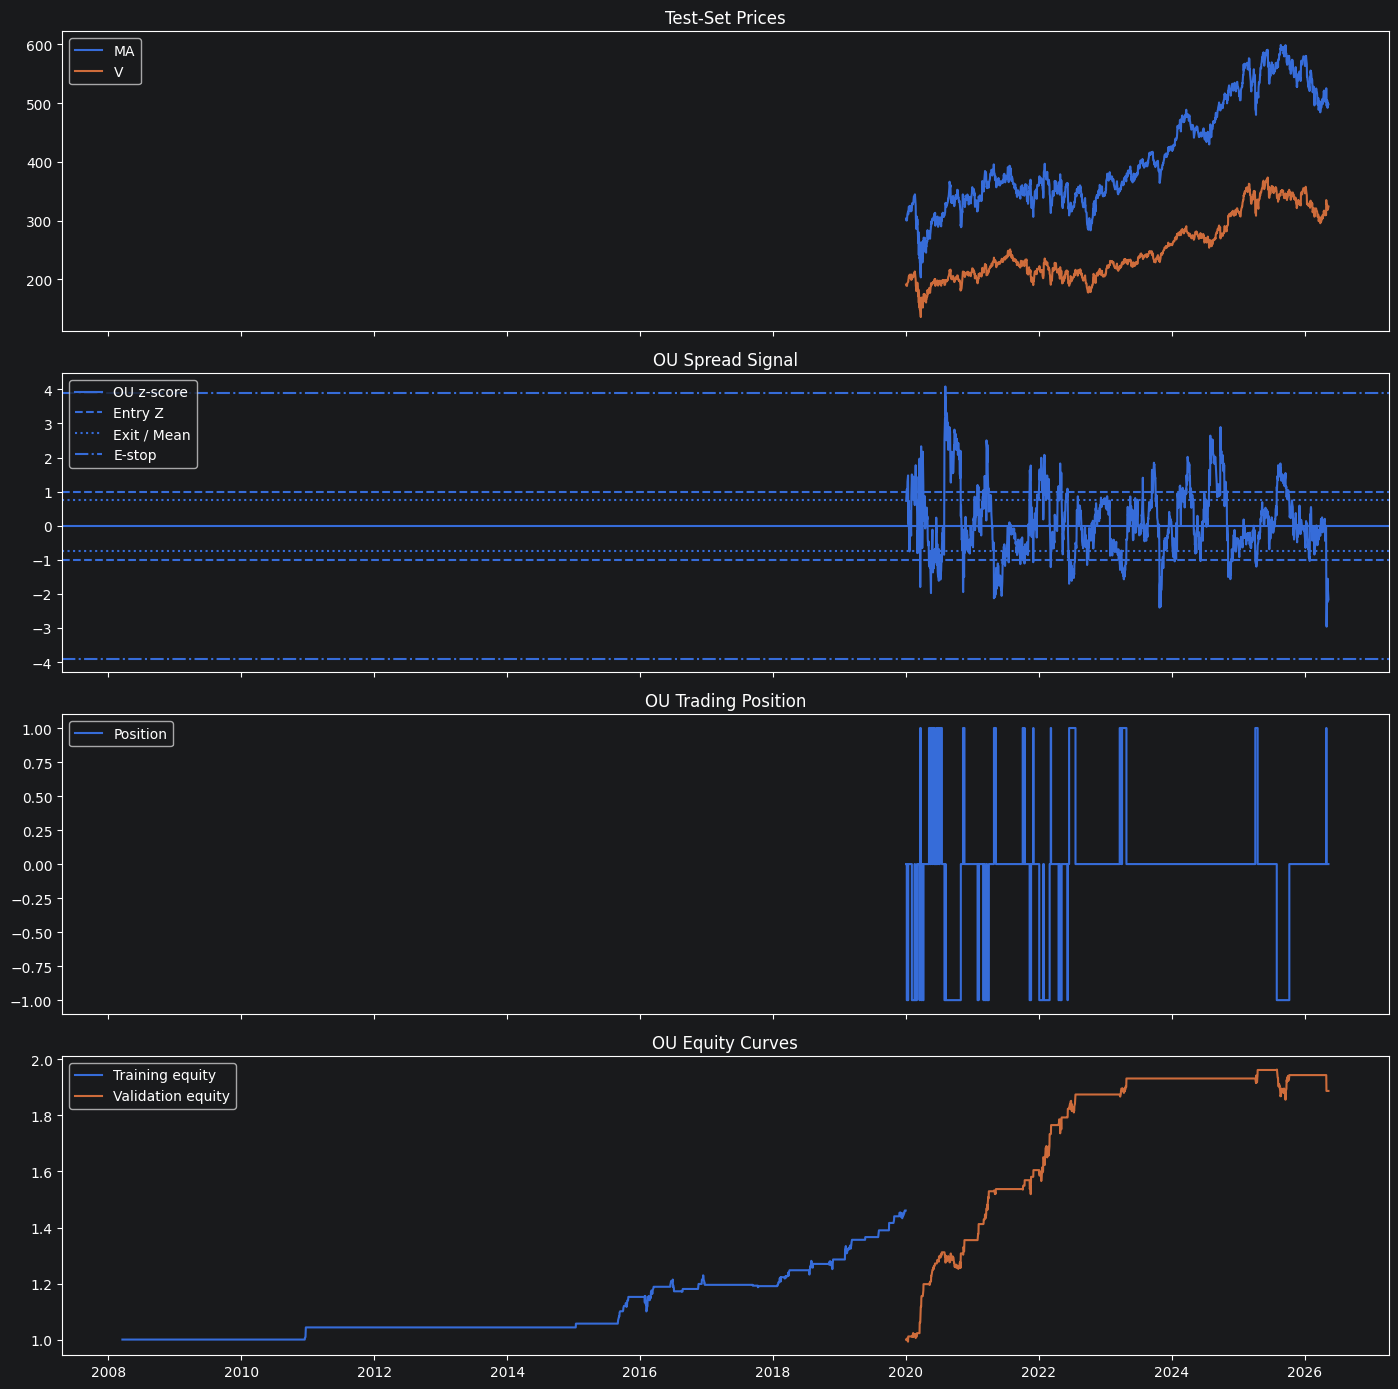

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(validation_df["Date"], validation_df["MA"], label="MA")
axes[0].plot(validation_df["Date"], validation_df["V"], label="V")
axes[0].set_title("Test-Set Prices")
axes[0].legend()

axes[1].plot(validation_df["Date"], validation_df["ou_z"], label="OU z-score")
axes[1].axhline(ENTRY_Z, linestyle="--", label="Entry Z")
axes[1].axhline(-ENTRY_Z, linestyle="--")
axes[1].axhline(EXIT_Z, linestyle=":", label="Exit / Mean")
axes[1].axhline(-EXIT_Z, linestyle=":")
axes[1].axhline(E_STOP, linestyle="-.", label="E-stop")
axes[1].axhline(-E_STOP, linestyle="-.")
axes[1].axhline(0, linestyle="-")
axes[1].set_title("OU Spread Signal")
axes[1].legend()

axes[2].step(validation_df["Date"], validation_df["position"], where="post", label="Position")
axes[2].set_title("OU Trading Position")
axes[2].legend()

axes[3].plot(training_df["Date"], training_df["equity_curve"], label="Training equity")
axes[3].plot(validation_df["Date"], validation_df["equity_curve"], label="Validation equity")
axes[3].set_title("OU Equity Curves")
axes[3].legend()

plt.tight_layout()
plt.show()


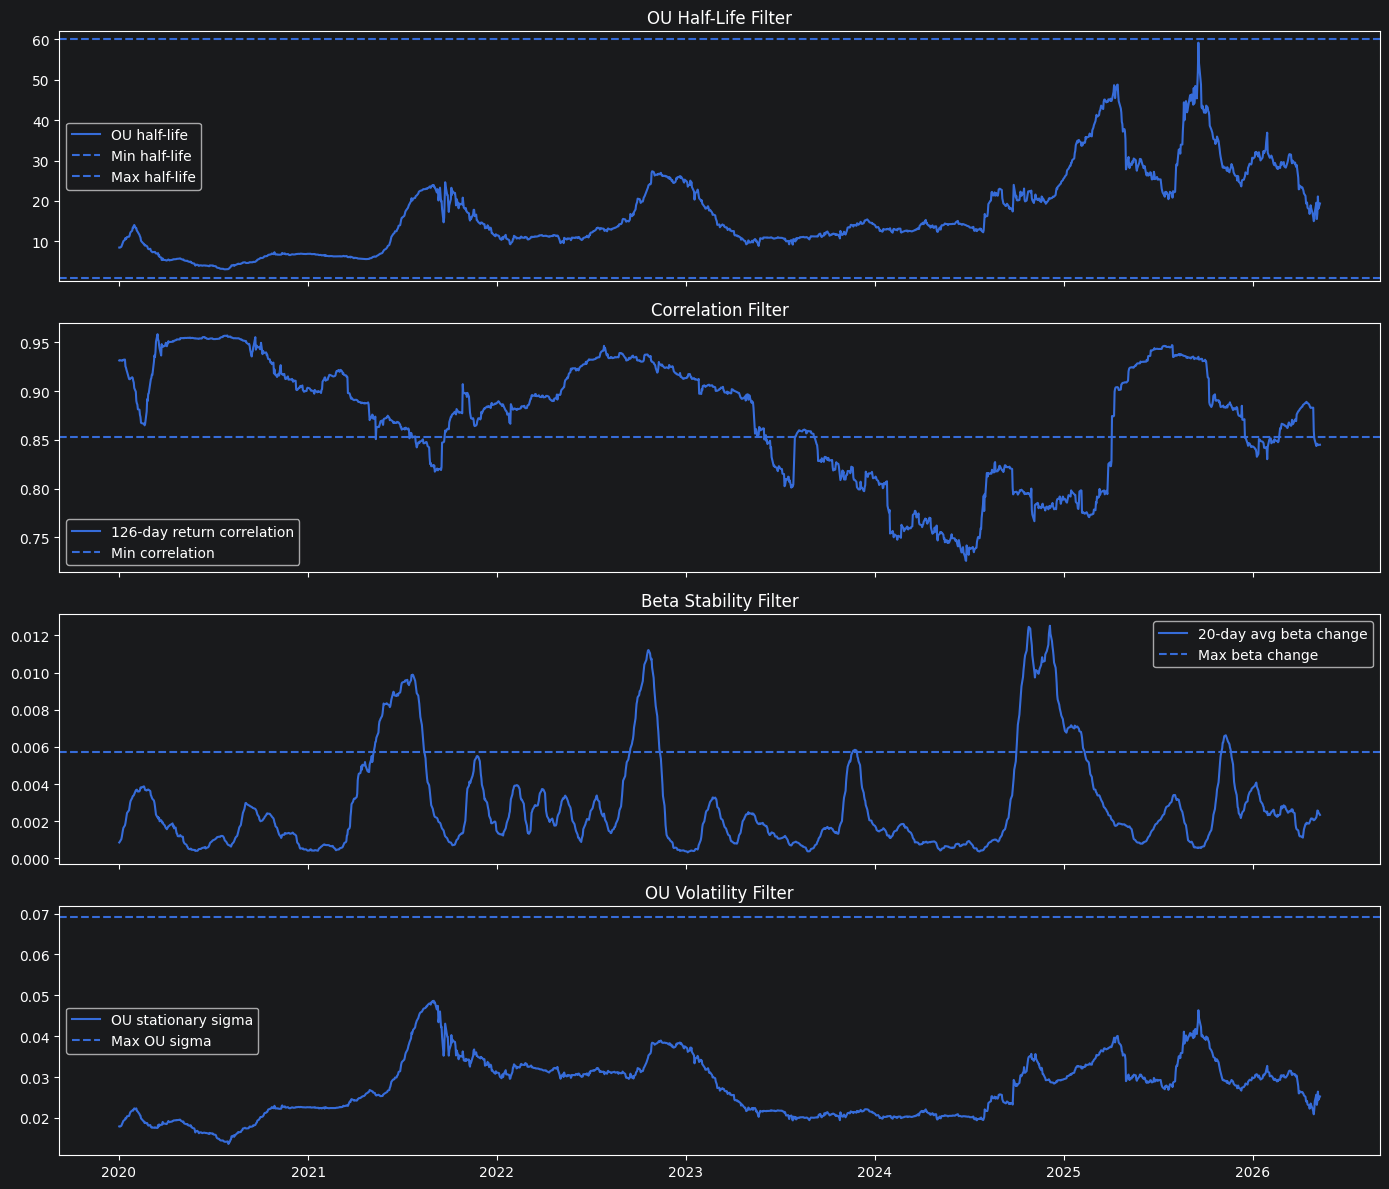

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(validation_df["Date"], validation_df["half_life"], label="OU half-life")
axes[0].axhline(MIN_HALF_LIFE, linestyle="--", label="Min half-life")
axes[0].axhline(MAX_HALF_LIFE, linestyle="--", label="Max half-life")
axes[0].set_title("OU Half-Life Filter")
axes[0].legend()

axes[1].plot(validation_df["Date"], validation_df["return_corr"], label="126-day return correlation")
axes[1].axhline(regime_thresholds["min_corr"], linestyle="--", label="Min correlation")
axes[1].set_title("Correlation Filter")
axes[1].legend()

axes[2].plot(validation_df["Date"], validation_df["beta_change_avg"], label="20-day avg beta change")
axes[2].axhline(regime_thresholds["max_beta_change"], linestyle="--", label="Max beta change")
axes[2].set_title("Beta Stability Filter")
axes[2].legend()

axes[3].plot(validation_df["Date"], validation_df["ou_sigma"], label="OU stationary sigma")
axes[3].axhline(regime_thresholds["max_ou_sigma"], linestyle="--", label="Max OU sigma")
axes[3].set_title("OU Volatility Filter")
axes[3].legend()

plt.tight_layout()
plt.show()
